In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
from sklearn.metrics import accuracy_score , classification_report
import warnings
import math

from rich import print
warnings.filterwarnings("ignore")

print("[green]Importing Libraries Successfully...[green]")

Importing Libraries Successfully...

In [5]:
df = pd.read_csv(r"C:\Users\athar\OneDrive\Documents\WineQT.csv" ,index_col='Id')

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Id,,,,,,,,,,,,
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Id,,,,,,,,,,,,
1592,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [8]:
df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Id,,,,,,,,,,,,
377,9.4,0.270,0.53,2.4,0.074,6.0,18.0,0.99620,3.20,1.13,12.0,7
253,7.7,0.775,0.42,1.9,0.092,8.0,86.0,0.99590,3.23,0.59,9.5,5
231,8.0,0.380,0.06,1.8,0.078,12.0,49.0,0.99625,3.37,0.52,9.9,6
656,10.7,0.430,0.39,2.2,0.106,8.0,32.0,0.99860,2.89,0.50,9.6,5
1380,7.5,0.570,0.02,2.6,0.077,11.0,35.0,0.99557,3.36,0.62,10.8,6


In [9]:
print("the no of rows:" , df.shape[0])
print("the no of columns:" , df.shape[1])

the no of rows: 1143

the no of columns: 12

In [10]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [11]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [12]:
df.shape

(1143, 12)

In [13]:
df.size

13716

In [14]:
print(df.nunique())

fixed acidity            91
volatile acidity        135
citric acid              77
residual sugar           80
chlorides               131
free sulfur dioxide      53
total sulfur dioxide    138
density                 388
pH                       87
sulphates                89
alcohol                  61
quality                   6
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1143 entries, 0 to 1597
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 116.1 KB


In [16]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [17]:
df.describe(include = 'all')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [18]:
df.describe().T.round(2).style.background_gradient(cmap='Greens') #.T = for transpose , round(2) = for rounding off till 2 decimal values
plt.show()

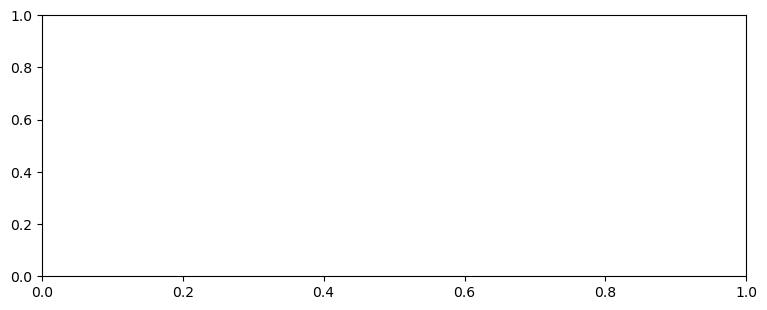

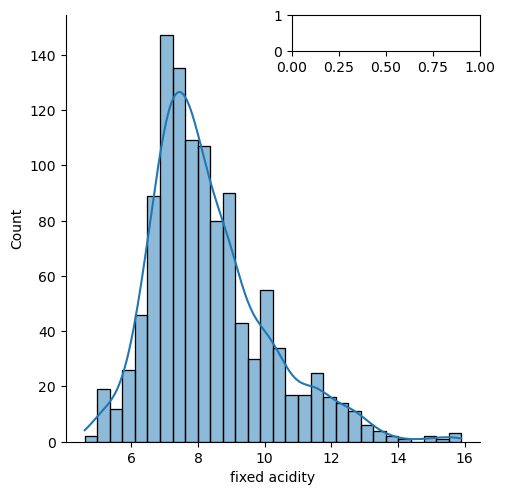

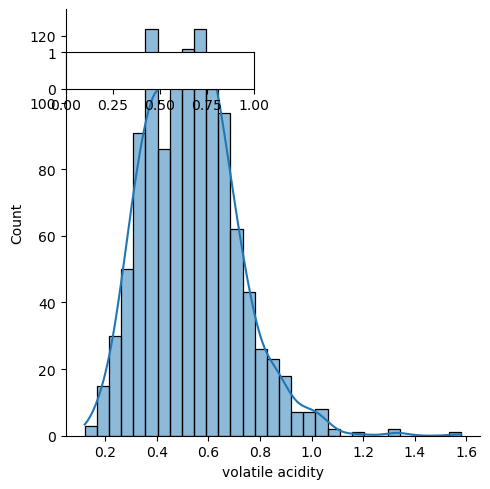

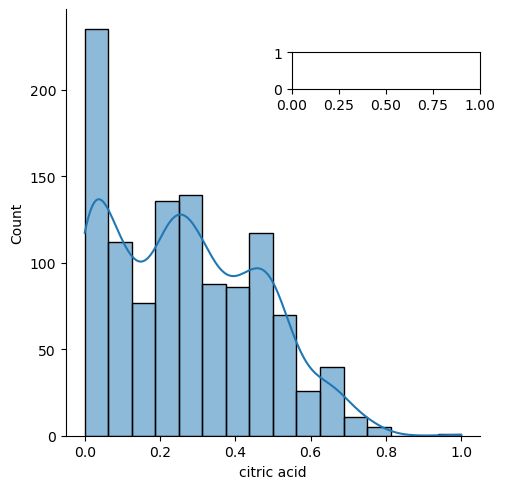

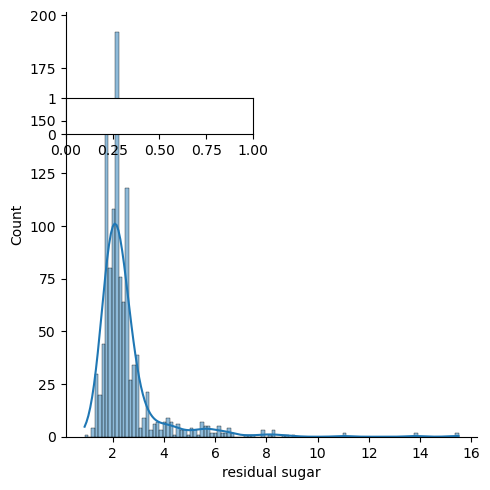

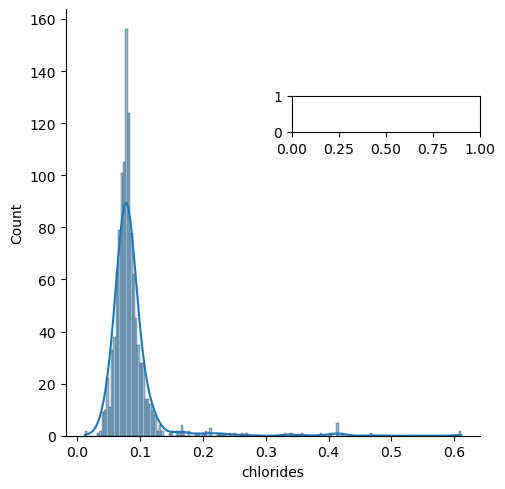

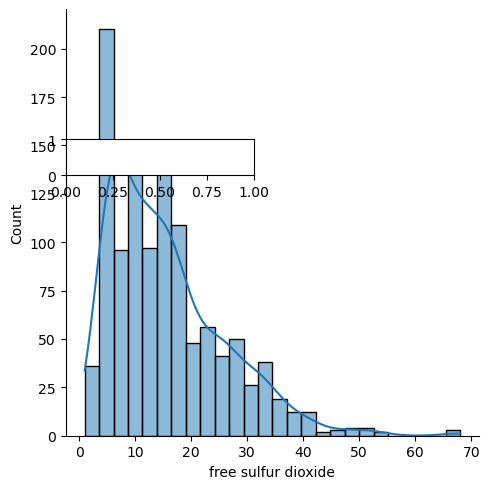

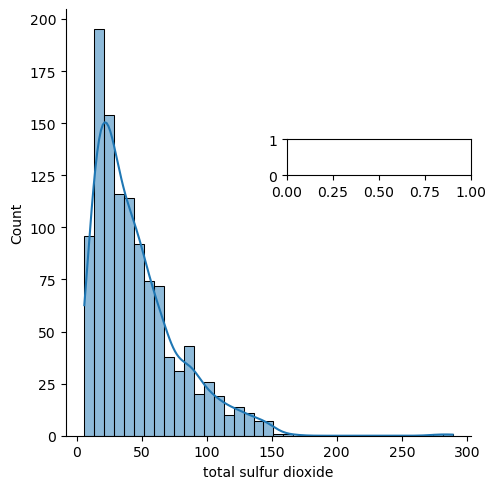

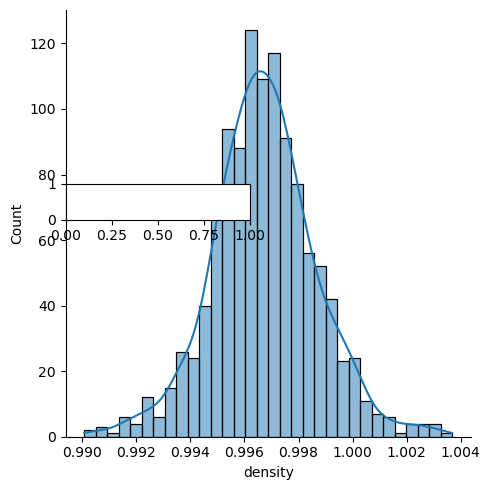

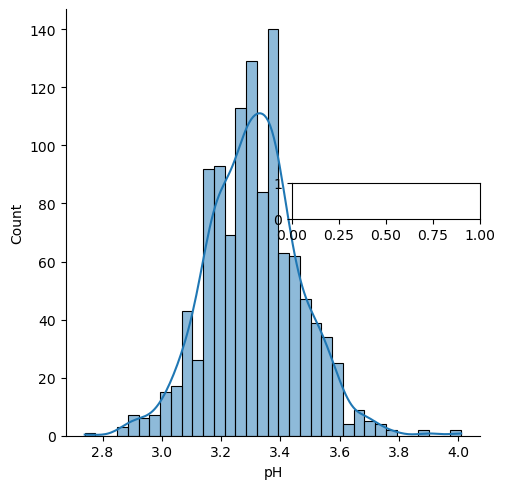

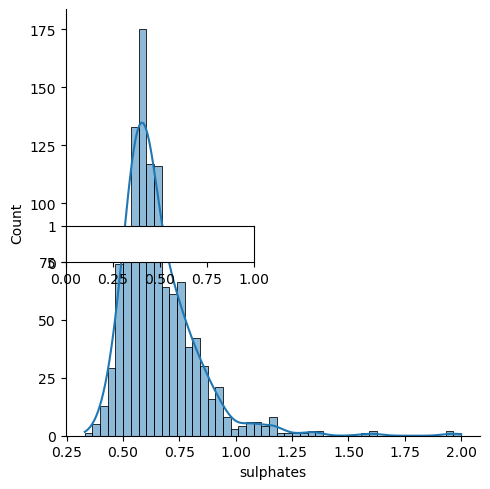

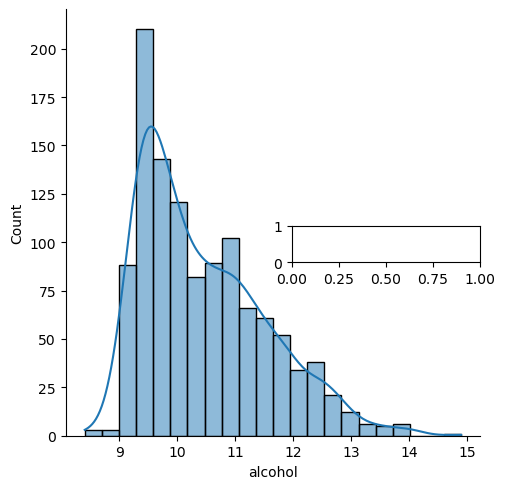

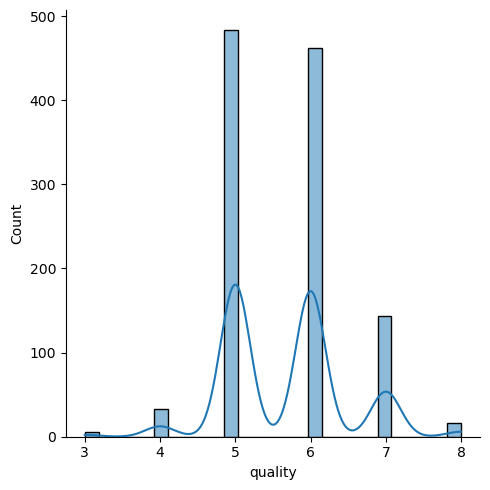

In [19]:
plt.figure(figsize=(20,40))
plotnum = 1
for columns in df :
    if plotnum <= len(df.columns):
        ax=plt.subplot(10,2,plotnum)
        sns.displot(df[columns] , kde=True)
        plotnum +=1
plt.tight_layout()
plt.show()

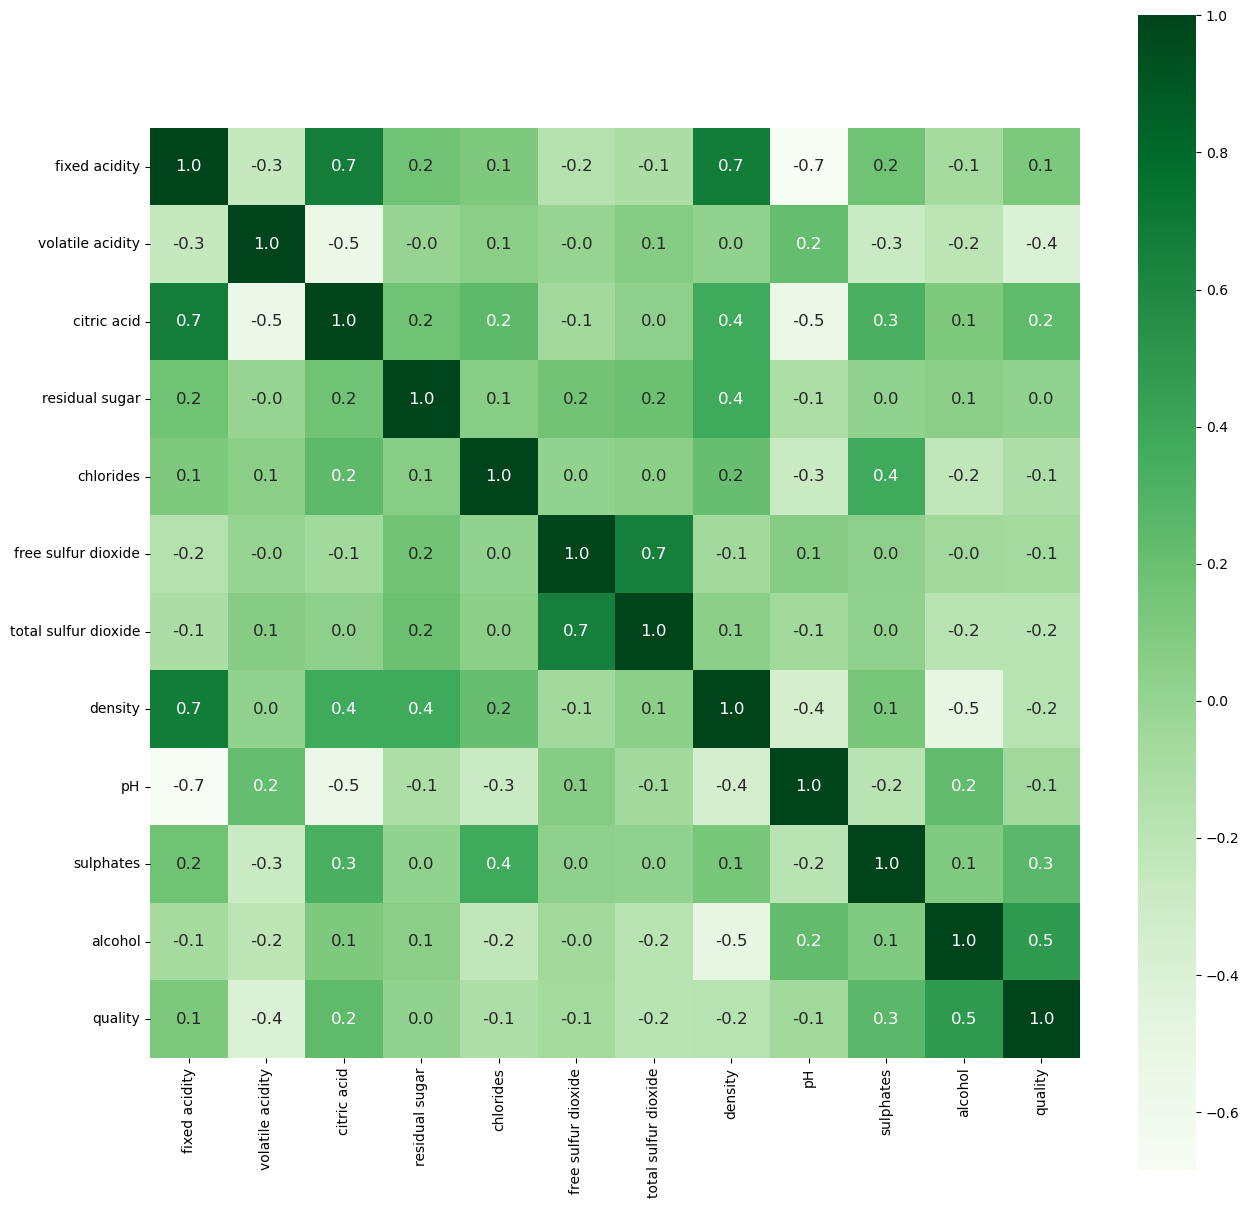

In [20]:
corr=df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr,fmt='.1f' , cbar=True,square=True,annot=True,annot_kws={'size':12} , cmap='Greens')
plt.show()

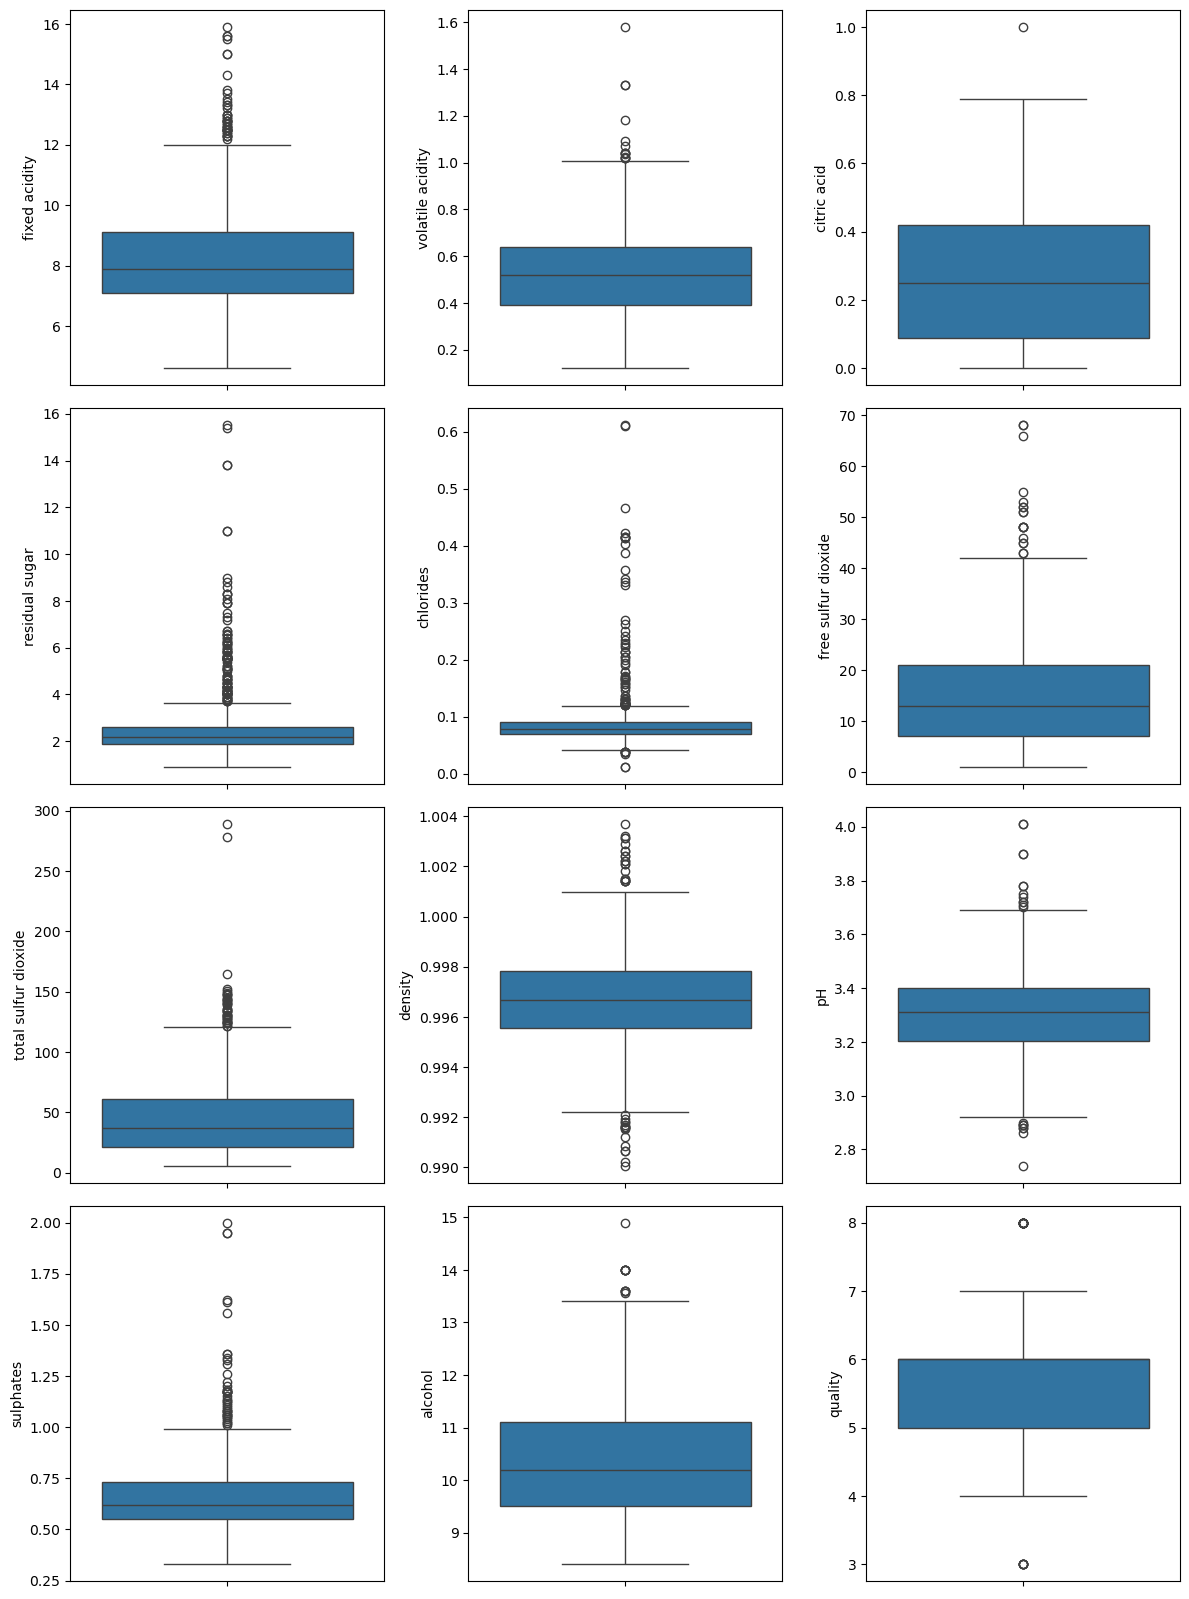

In [21]:
plt.figure(figsize=(12,20))
plotnum = 1
for columns in df :
    if plotnum <= len(df.columns) :
        ax=plt.subplot(5,3,plotnum)
        sns.boxplot(y=df[columns])
    plotnum +=1
plt.tight_layout()
plt.show()

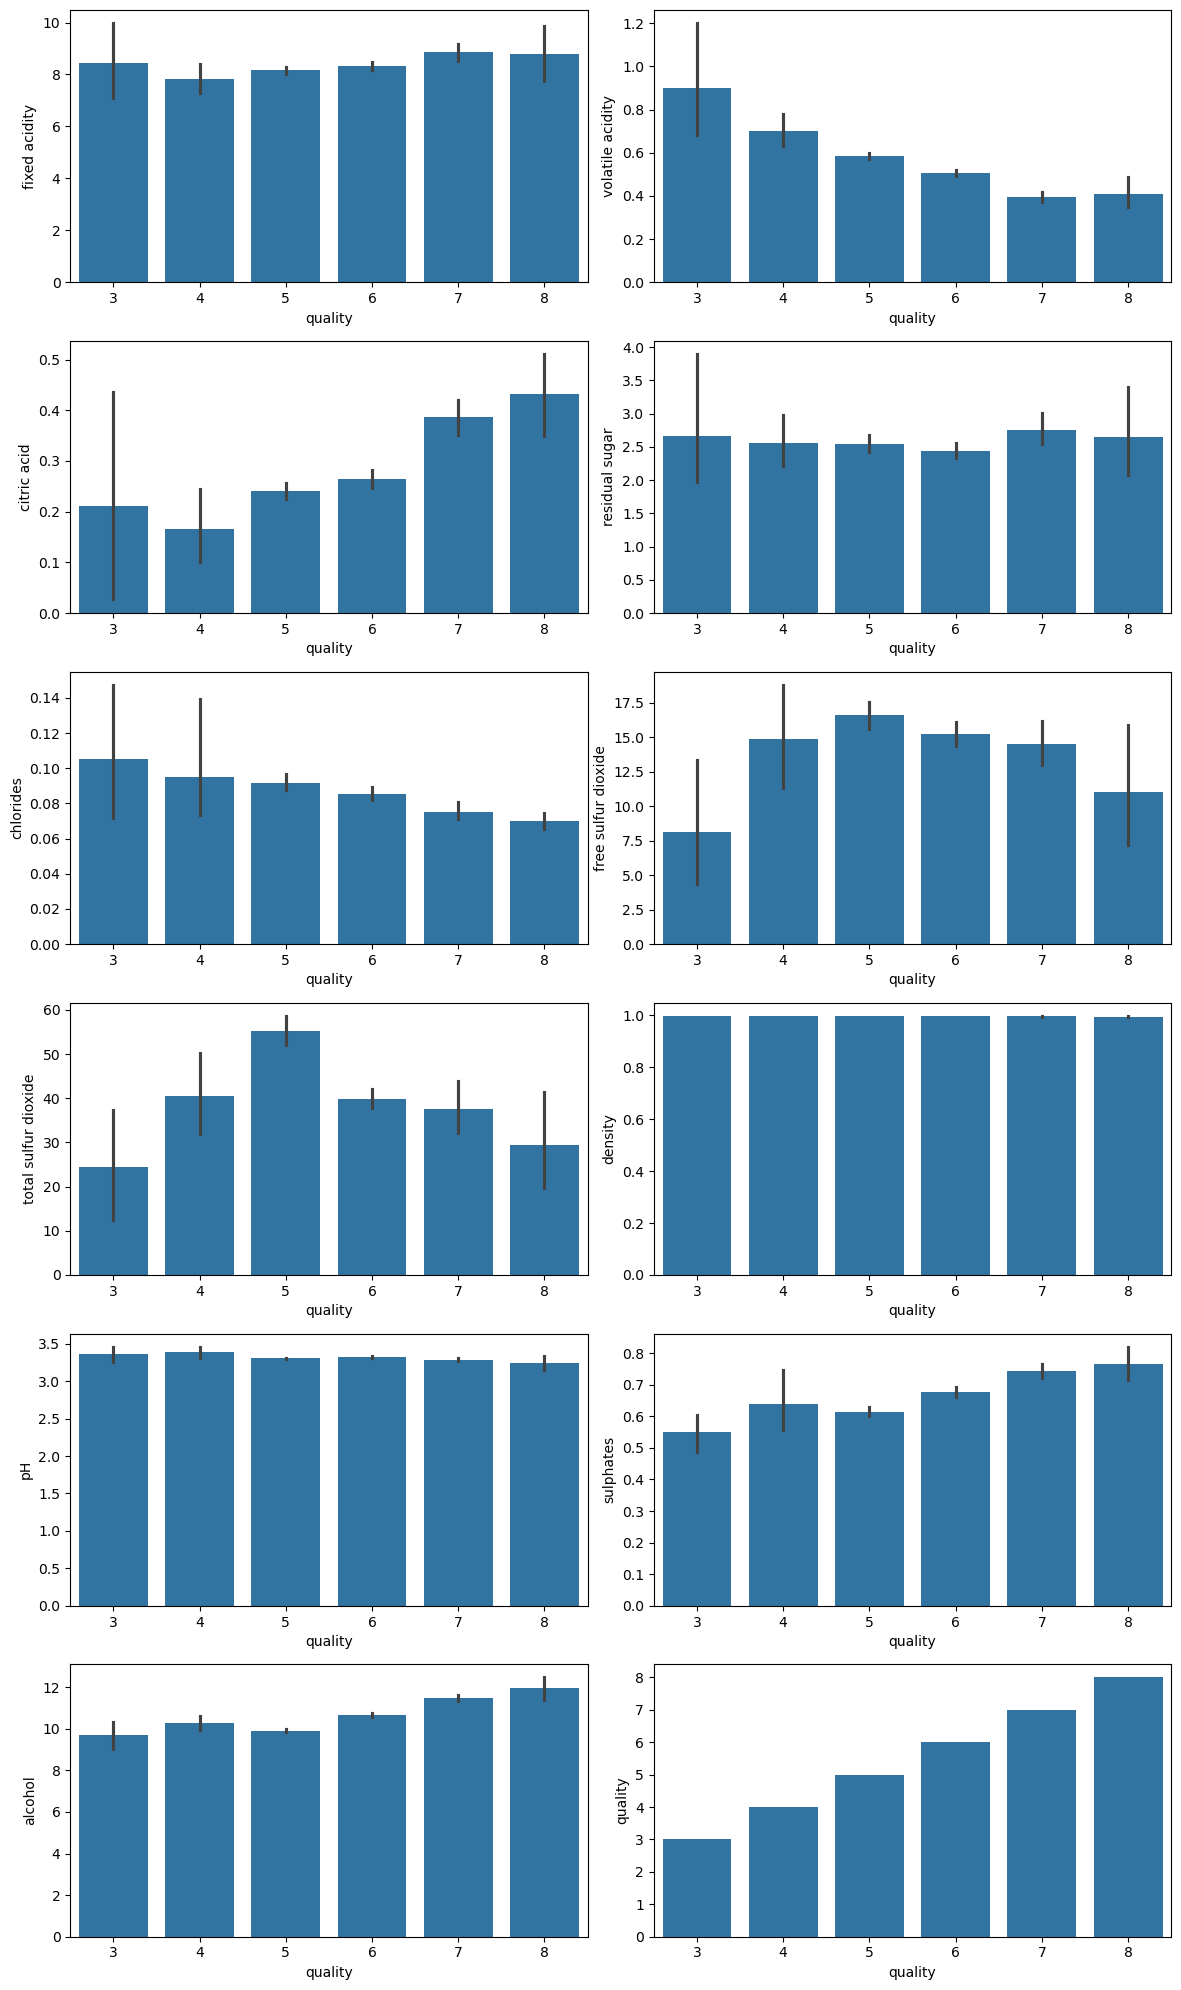

In [22]:
plt.figure(figsize=(12,20))
plotnum = 1
for columns in df :
    if plotnum <= len(df.columns) :
        ax=plt.subplot(6,2,plotnum)
        sns.barplot(x='quality' , y=df[columns] , data=df)
    plotnum +=1
plt.tight_layout()
plt.show()

In [23]:
print(f"\nValue counts for quality:")
print(df['quality'].value_counts().sort_values(ascending=False))

Value counts for quality:

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

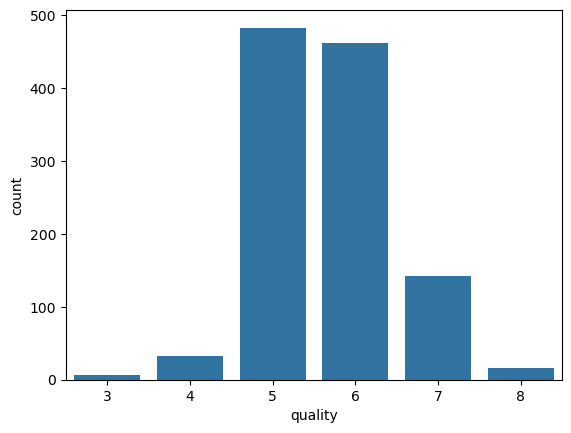

In [24]:
sns.countplot(x=df['quality'],data=df)
plt.show()

In [25]:
print(df.skew()) # skew means if the tail of the data is longer it might be in right or in the left

fixed acidity           1.044930
volatile acidity        0.681547
citric acid             0.371561
residual sugar          4.361096
chlorides               6.026360
free sulfur dioxide     1.231261
total sulfur dioxide    1.665766
density                 0.102395
pH                      0.221138
sulphates               2.497266
alcohol                 0.863313
quality                 0.286792
dtype: float64

In [26]:
print(df.kurt()) # kurt means how long the data's head is ; if head is long then no.of outliers are more.

fixed acidity            1.384614
volatile acidity         1.375531
citric acid             -0.714686
residual sugar          27.675366
chlorides               47.078324
free sulfur dioxide      1.932170
total sulfur dioxide     5.098748
density                  0.888123
pH                       0.925791
sulphates               12.017377
alcohol                  0.221179
quality                  0.314664
dtype: float64

In [27]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [28]:
print('the number of null in DataFrame is :' , df.isnull().sum().sum())
print('the number of NAN in DataFrame is :' , df.isna().sum().sum())
print('the number of Duplicated in DataFrame is :' , df.duplicated().sum().sum())

the number of null in DataFrame is : 0

the number of NAN in DataFrame is : 0

the number of Duplicated in DataFrame is : 125

In [29]:
df.drop_duplicates(inplace=True)

In [30]:
print('the number of null in DataFrame is :' , df.isnull().sum().sum())
print('the number of NAN in DataFrame is :' , df.isna().sum().sum())
print('the number of Duplicated in DataFrame is :' , df.duplicated().sum().sum())

the number of null in DataFrame is : 0

the number of NAN in DataFrame is : 0

the number of Duplicated in DataFrame is : 0

In [31]:
X = df.iloc[: , :-1].values
Y = df.iloc[:,-1].values
print("[green]Seprating Sucessfully...[green]")

Seprating Sucessfully...

In [32]:
X

array([[ 7.4  ,  0.7  ,  0.   , ...,  3.51 ,  0.56 ,  9.4  ],
       [ 7.8  ,  0.88 ,  0.   , ...,  3.2  ,  0.68 ,  9.8  ],
       [ 7.8  ,  0.76 ,  0.04 , ...,  3.26 ,  0.65 ,  9.8  ],
       ...,
       [ 6.2  ,  0.6  ,  0.08 , ...,  3.45 ,  0.58 , 10.5  ],
       [ 5.9  ,  0.55 ,  0.1  , ...,  3.52 ,  0.76 , 11.2  ],
       [ 5.9  ,  0.645,  0.12 , ...,  3.57 ,  0.71 , 10.2  ]])

In [33]:
Y

array([5, 5, 5, ..., 5, 6, 5], dtype=int64)

In [34]:
len(X)

1018

In [109]:
len(Y)

1018

### Data Sampling

In [36]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state = 42) # SMOTE used for data balencning thats the data cannot be trained over the specific data
X_resampled ,Y_resampled = smote.fit_resample(X,Y)

print("Resampled class distribution:" , Counter(Y_resampled))

Resampled class distribution:
Counter({5: 433, 6: 433, 7: 433, 4: 433, 8: 433, 3: 433})

In [37]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler() # Robust scaler used to avoid outliers and focused on the good data which is efectiive for the model

X_resampled = scaler.fit_transform(X_resampled)

### Robustscaler scales features using the median and interquartiles range (IQR) instead of the mean , making it robust to outliers and extreme values commonly found in chemical measurments 

In [39]:
X_resampled.std()

1.090002553146717

In [40]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X_resampled , Y_resampled,test_size=0.2,random_state=11)

In [41]:
print("x shape:" , X.shape)
print("y shape:" , Y.shape)

print("x_train shape:" , X_train.shape)
print("x_test shape:" , X_test.shape)

print("y_train shape:" , Y_train.shape)
print("y_test shape:" , Y_test.shape)

x shape:
(1018, 11)

y shape:
(1018,)

x_train shape:
(2078, 11)

x_test shape:
(520, 11)

y_train shape:
(2078,)

y_test shape:
(520,)

In [42]:
results=[]
def training_models(model_name , model):
    # Train the model
    model.fit(X_train,Y_train)

    #Predict on trainig and test data
    X_train_pred = model.predict(X_train)
    X_test_pred = model.predict(X_test)
    
    #Accuracy scores
    accuracy_train = accuracy_score(Y_train , X_train_pred)
    accuracy_test = accuracy_score(Y_test , X_test_pred)

    # Classifiaaction 
    report = classification_report(Y_test , X_test_pred)
    
    #print results with formatting 
    print(f"[bold cyan]The Accuracy score of traing by {model_name} (train):[/bold cyan] {accuracy_train:.2f}")
    print(f"[bold magneta]The Accuracy score of trainig by {model_name} (test):[/bold magneta] {accuracy_test:.2f}")

    print("[bold yellow] classsification report : [/bold yellow]")
    print(report)

    #Completion message 
    print("[bold green]Traing complete...[/bold green]")

    #save results
    results.append({
        "Model": model_name ,
        "Test Accuracy" : accuracy_test
    })

In [43]:
from sklearn.linear_model import LogisticRegression 
log = LogisticRegression() 
training_models("Logistic Regression " , log)

The Accuracy score of traing by Logistic Regression  (train): 0.64

The Accuracy score of trainig by Logistic Regression  (test): 0.63

 classsification report : 

precision    recall  f1-score   support

           3       0.86      0.96      0.91        85
           4       0.65      0.56      0.60        94
           5       0.52      0.58      0.55        79
           6       0.46      0.39      0.43        84
           7       0.54      0.51      0.52        89
           8       0.69      0.76      0.72        89

    accuracy                           0.63       520
   macro avg       0.62      0.63      0.62       520
weighted avg       0.62      0.63      0.62       520

Traing complete...

In [44]:
from sklearn.tree import DecisionTreeClassifier

dest = DecisionTreeClassifier()
training_models("Decision TreeClassifier" , dest)

The Accuracy score of traing by Decision TreeClassifier (train): 1.00

The Accuracy score of trainig by Decision TreeClassifier (test): 0.77

 classsification report : 

precision    recall  f1-score   support

           3       0.98      0.96      0.97        85
           4       0.79      0.83      0.81        94
           5       0.58      0.57      0.57        79
           6       0.49      0.44      0.47        84
           7       0.80      0.87      0.83        89
           8       0.92      0.91      0.92        89

    accuracy                           0.77       520
   macro avg       0.76      0.76      0.76       520
weighted avg       0.76      0.77      0.77       520

Traing complete...

In [45]:
from sklearn.ensemble import RandomForestClassifier
randf = RandomForestClassifier()
training_models("Random Forest Classifier", randf)

The Accuracy score of traing by Random Forest Classifier (train): 1.00

The Accuracy score of trainig by Random Forest Classifier (test): 0.83

 classsification report : 

precision    recall  f1-score   support

           3       0.99      1.00      0.99        85
           4       0.89      0.93      0.91        94
           5       0.64      0.65      0.64        79
           6       0.59      0.46      0.52        84
           7       0.84      0.91      0.87        89
           8       0.94      0.98      0.96        89

    accuracy                           0.83       520
   macro avg       0.81      0.82      0.81       520
weighted avg       0.82      0.83      0.82       520

Traing complete...

In [46]:
from sklearn.svm import SVC
SVC = SVC()
training_models("SVC" , SVC)

The Accuracy score of traing by SVC (train): 0.78

The Accuracy score of trainig by SVC (test): 0.72

 classsification report : 

precision    recall  f1-score   support

           3       0.87      1.00      0.93        85
           4       0.80      0.77      0.78        94
           5       0.55      0.56      0.55        79
           6       0.46      0.39      0.42        84
           7       0.73      0.69      0.71        89
           8       0.81      0.89      0.85        89

    accuracy                           0.72       520
   macro avg       0.70      0.71      0.71       520
weighted avg       0.71      0.72      0.71       520

Traing complete...

In [47]:
from sklearn.naive_bayes import GaussianNB
guss = GaussianNB()
training_models("GaussianNB" , guss)

The Accuracy score of traing by GaussianNB (train): 0.55

The Accuracy score of trainig by GaussianNB (test): 0.53

 classsification report : 

precision    recall  f1-score   support

           3       0.58      1.00      0.74        85
           4       0.50      0.37      0.43        94
           5       0.51      0.38      0.43        79
           6       0.36      0.24      0.29        84
           7       0.48      0.34      0.40        89
           8       0.59      0.85      0.70        89

    accuracy                           0.53       520
   macro avg       0.51      0.53      0.50       520
weighted avg       0.51      0.53      0.50       520

Traing complete...

In [48]:
results_df = pd.DataFrame(results)
print(results_df.sort_values(by="Test Accuracy" , ascending=False))

Model  Test Accuracy
2  Random Forest Classifier       0.826923
1   Decision TreeClassifier       0.769231
3                       SVC       0.719231
0      Logistic Regression        0.628846
4                GaussianNB       0.530769

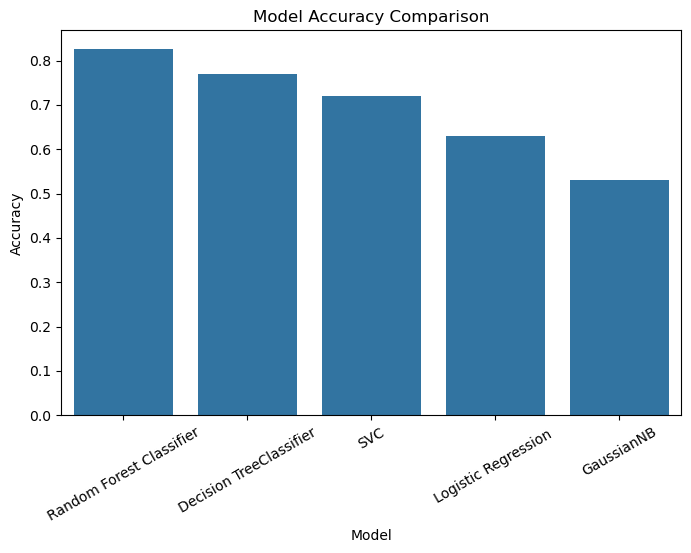

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model' , y="Test Accuracy" , data = results_df.sort_values(by='Test Accuracy' , ascending = False))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

plt.show()

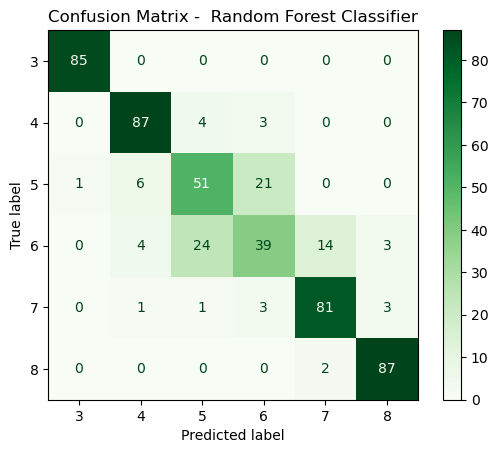

In [50]:
# Identify the best model
best_model_name = results_df.sort_values(by="Test Accuracy" , ascending = False).iloc[0]["Model"]

model_dict = {
    "Logistic REgression": log,
    "Decision TreeClassifier":  dest,
    "Random Forest Classifier":  randf,
    "SVC":  SVC,
     "GaussianNB":  guss
}

best_model = model_dict[best_model_name]

# Prediction 
Y_pred = best_model.predict(X_test)

#Confusion Matrix
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
cm = confusion_matrix(Y_test,Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm , display_labels=np.unique(Y_test))
disp.plot(cmap='Greens' , values_format='d')
plt.title(f"Confusion Matrix -  {best_model_name}")
plt.show()

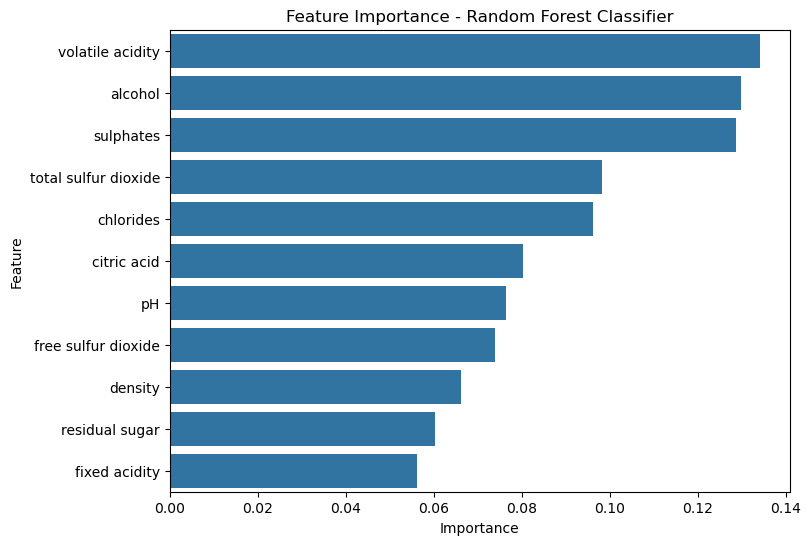

In [51]:
if hasattr(best_model , 'feature_importances_'): 
    importances = pd.DataFrame({
        'Feature': df.columns[:-1] , 
        'Importance' : best_model.feature_importances_
    }).sort_values(by='Importance' , ascending=False) 

    plt.figure(figsize=(8,6)) 
    sns.barplot(x = 'Importance' , y='Feature' , data=importances) 
    plt.title(f"Feature Importance - {best_model_name}") 
    plt.show() 

else: 
  print(f"{best_model_name} does not provide feature importance.")

In [52]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [53]:
import numpy as np 

new_wine = np.array([[7.4,0.7,0.0,1.9,0.076,
                      11.0,34.0,0.9978,3.51,0.56,9.4]])

new_wine_sclaed = scaler.transform(new_wine) 

predicted_quality = randf.predict(new_wine_sclaed) 

print(f"Predicted wine Quality: {predicted_quality[0]}")
                                   

Predicted wine Quality: 5

In [54]:
import joblib 
from sklearn.preprocessing import StandardScaler 

#Step-1 : scale your traing data (if not already done)
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

#Step - 2 : Retrain your best model on the full scaled training data
best_model = RandomForestClassifier() 
best_model.fit(X_train_scaled , Y_train) 

#Step-3 : Save the model and scaler
joblib.dump(best_model , "wine_model.pkl") 
joblib.dump(scaler , "wine_scaler.pkl") 
print("Model and scaler saved sucessfully!")

Model and scaler saved sucessfully!

In [55]:
model = joblib.load("wine_model.pkl") 
scaler = joblib.load("wine_scaler.pkl") 

#Example wine data
features = np.array([[8.6,4.7,5.2,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.54]])
features_scaled = scaler.transform(features) 

prediction = model.predict(features_scaled)

print("Prediction wine quality:" , int(prediction[0]))

Prediction wine quality: 5